# UpSet plots & intersections

Generates upset plots in [Fig. 2](figures/figure_2) and [Fig. 6](figures/figure_6) as well as [Supplementary Table 6](results/Supplementary_Table_6_Hit_Intersections.xlsx).

Note: this notebook will not run with the main `orb-selection` conda environment for this repo due to upsetplot incompatibilities; try the [`upset_env.yml`](upset_env.yml) environment instead.

## Notebook Workflow

1. Load significant gene-ID lists from each analysis branch.
2. Build set intersections and UpSet visualizations.
3. Optionally intersect with silk-gland-associated gene sets.
4. Save publication-ready figures to `figures/`.

In [14]:
import os
import sys
import pip
import warnings
!{sys.executable} -m pip install openpyxl
import upsetplot as up
import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

data = os.path.join(repo_root, "data")

src_path = os.path.join(repo_root, "src")
stage03_path = os.path.join(repo_root, "scripts", "03_selection_tests")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage03_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-03 path: {stage03_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import the modules from src/
from hyphy_results_parser import (
    RelaxResult,
    BustedPhResult
)
from odds_ratio_test import PermutationTestResults
from id_converter import convert_hogs_to_locs, convert_locs_to_hogs, get_ptep_description

import get_silk_genes as silk

# Define paths to data and results directories
data = os.path.join(repo_root, "data")
figures = os.path.join(repo_root, "figures")
assets = os.path.join(repo_root, "assets")
results = os.path.join(repo_root, "results")

# Suppress FutureWarnings and SyntaxWarnings from libraries (especially upsetplot)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)

%load_ext autoreload

up.__version__

Using src path: /Users/calvin/orb-selection/src
Using stage-03 path: /Users/calvin/orb-selection/scripts/03_selection_tests
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'0.9.0'

## Read all the hit lists into a dictionary (as HOGs)

In [15]:
hits_lists = {}

### Silk gland genes & spidroins

In [16]:
%autoreload 2
silk_genes_list = silk.get_all_silk_genes(data)
spidroins_list = pd.read_csv(f'{data}/spidroins_LOCs.tsv', sep='\t', dtype=str)['LOC'].tolist()

# There may end up being LOCs in these HOGs that are not in my silk gland gene list
# or spidroin list. However, if they are orthologous to those LOCs, they are still relevant.
silk_hogs = convert_locs_to_hogs(silk_genes_list, f'{data}/N5.tsv')
spidroin_hogs = convert_locs_to_hogs(spidroins_list, f'{data}/N5.tsv')

# These lists of HOGs are longer than the original lists of LOCs, meaning some LOCs 
# belong to multiple HOGs. This may be because multiple isoforms of the gene were 
# included in the original Orthofinder analysis.
hits_lists['silk_genes'] = list(set(silk_hogs['HOG'].tolist()))
hits_lists['spidroins'] = list(set(spidroin_hogs['HOG'].tolist()))

### Hyphy results

In [17]:
hyphy_results = results + "/hyphy_results_cache/"

# Load the saved RELAX results
relax_result = RelaxResult.load_from_pickle(str(hyphy_results + "relax_results.pkl"))
relax_result_fltrd = relax_result.filter_omega(10000)
relax_df_fltrd = relax_result_fltrd.results_df
hits_lists['relaxed_in_nonorb'] = list(relax_df_fltrd[relax_df_fltrd['result']=='relaxed'].index)
hits_lists['intensified_in_nonorb'] = list(relax_df_fltrd[relax_df_fltrd['result']=='intensified'].index)

# Load the saved BUSTED-PH results
busted_ph_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_results.pkl"))
busted_ph_result_fltrd = busted_ph_result.filter_omega(10000)
busted_ph_df_fltrd = busted_ph_result_fltrd.results_df
hits_lists['positive_sel_in_orb'] = list(busted_ph_df_fltrd[busted_ph_df_fltrd['result']=='hit'].index)

# Load the saved BUSTED-PH-REV results
busted_ph_rev_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_rev_results.pkl"))


busted_ph_rev_result_fltrd = busted_ph_rev_result.filter_omega(10000)
busted_ph_rev_df_fltrd = busted_ph_rev_result_fltrd.results_df
hits_lists['positive_sel_in_nonorb'] = list(busted_ph_rev_df_fltrd[busted_ph_rev_df_fltrd['result']=='hit'].index)

### Odds ratio test results

In [18]:
perm_test_results_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Aug12/Run1_occ_30-88_10000x")
perm_results = pd.read_csv(os.path.join(perm_test_results_dir, "fltrd_hits.csv"), index_col="HOG")

In [19]:
perm_results

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001041,46,2.521478,-0.155768,0.0009,0.9991,0.4798,0.5202,NaN,loss_fg
N5.HOG0001627,33,1.855831,-3.857911,0.0640,0.9360,0.9873,0.0127,dup_bg,dup_bg
N5.HOG0002031,46,-3.395453,1.332164,0.9984,0.0016,0.4120,0.5880,loss_bg,loss_bg
N5.HOG0002072,52,3.079265,-0.639315,0.0143,0.9857,0.8034,0.1964,loss_fg,loss_fg
N5.HOG0002076,55,-2.050543,0.725386,0.9545,0.0455,0.1584,0.8416,NaN,loss_bg
...,...,...,...,...,...,...,...,...,...
N5.HOG0073071,35,-2.150469,2.393444,0.7460,0.2540,0.0113,0.9887,dup_fg,dup_fg
N5.HOG0073090,32,1.527411,-1.712408,0.0256,0.9744,0.9150,0.0850,NaN,loss_fg
N5.HOG0073180,32,-1.042447,0.851411,0.9953,0.0047,0.1060,0.8940,NaN,loss_bg


Break down into HOGs that were more likely to be missing or in multiple copies in orbweavers or in non-orbweavers

In [24]:
hits_lists['duplication_more_likely_orb'] = list(perm_results[perm_results["P-value duplication more likely in fg"] <= 0.05].index)
hits_lists['duplication_more_likely_nonorb'] = list(perm_results[perm_results["P-value duplication more likely in bg"] <= 0.05].index)
hits_lists['loss_more_likely_orb'] = list(perm_results[perm_results["P-value loss more likely in fg"] <= 0.05].index)
hits_lists['loss_more_likely_nonorb'] = list(perm_results[perm_results["P-value loss more likely in bg"] <= 0.05].index)

Save significant HOGs for GO enrichment with ptep

In [ ]:
with open(os.path.join(perm_test_results_dir, "loc_lists/dup_bg_sig_hogs.txt"), 'w') as f:
    for item in hits_lists['duplication_more_likely_nonorb']:
        f.write(f"{item}\n")

with open(os.path.join(perm_test_results_dir, "loc_lists/loss_fg_sig_hogs.txt"), 'w') as f:
    for item in hits_lists['loss_more_likely_orb']:
        f.write(f"{item}\n")

Save hits with CI thresholds

In [38]:
hits_lists['duplication_more_likely_orb'] = list(perm_results[(perm_results["P-value duplication more likely in fg"] <= 0.05) & (perm_results["Significant by avgd thresholds"].str.contains("dup_fg"))].index)
hits_lists['duplication_more_likely_nonorb'] = list(perm_results[(perm_results["P-value duplication more likely in bg"] <= 0.05) & (perm_results["Significant by avgd thresholds"].str.contains("dup_bg"))].index)
hits_lists['loss_more_likely_orb'] = list(perm_results[(perm_results["P-value loss more likely in fg"] <= 0.05) & (perm_results["Significant by avgd thresholds"].str.contains("loss_fg"))].index)
hits_lists['loss_more_likely_nonorb'] = list(perm_results[(perm_results["P-value loss more likely in bg"] <= 0.05) & (perm_results["Significant by avgd thresholds"].str.contains("loss_bg"))].index)

In [ ]:
with open(os.path.join(perm_test_results_dir, "loc_lists/dup_bg_sig_hogs_avg_ci.txt"), 'w') as f:
    for item in dup_nonorb_avg_ci:
        f.write(f"{item}\n")

with open(os.path.join(perm_test_results_dir, "loc_lists/loss_fg_sig_hogs_avg_ci.txt"), 'w') as f:
    for item in loss_orb_avg_ci:
        f.write(f"{item}\n")

### PhyloGLM results

In [39]:
phyloglm = pd.read_csv(f'{results}/phyloglm/phyloglm_qvals.csv', index_col="HOG")
phyloglm_sig = phyloglm[phyloglm["qvalue"] <= 0.01]
phyloglm_sig.head()

,error,coef_.Intercept._Estimate,coef_.Intercept._StdErr,coef_.Intercept._z.value,coef_.Intercept._p.value,coef_orb_weavingTRUE_Estimate,coef_orb_weavingTRUE_StdErr,coef_orb_weavingTRUE_z.value,coef_orb_weavingTRUE_p.value,qvalue
HOG,,,,,,,,,,
N5.HOG0000608,NaN,0.092585,0.160800,0.575779,0.564764,0.273735,0.071194,3.844943,0.000121,0.001440
N5.HOG0002047,NaN,-1.321608,0.621012,-2.128153,0.033324,1.126103,0.334118,3.370377,0.000751,0.005910
N5.HOG0002053,NaN,-0.115574,0.367135,-0.314799,0.752914,0.800547,0.178541,4.483840,0.000007,0.000163
N5.HOG0002054,NaN,-0.359228,0.274927,-1.306629,0.191339,0.432641,0.122849,3.521733,0.000429,0.003899
N5.HOG0002163,NaN,-0.558401,0.383995,-1.454189,0.145894,0.869823,0.190683,4.561625,0.000005,0.000124


In [40]:
hits_lists['phyloglm_fg'] = list(phyloglm_sig[phyloglm_sig["coef_orb_weavingTRUE_Estimate"] > 0].index)
hits_lists['phyloglm_bg'] = list(phyloglm_sig[phyloglm_sig["coef_orb_weavingTRUE_Estimate"] < 0].index)
# hits_lists['phyloglm_all'] = list(phyloglm_sig.index)

In [41]:
print("Hits lists:")
for category, hits in hits_lists.items():
    print(f"  {category}: {len(hits)}") 

Hits lists:
  silk_genes: 481
  spidroins: 27
  relaxed_in_nonorb: 491
  intensified_in_nonorb: 938
  positive_sel_in_orb: 96
  positive_sel_in_nonorb: 196
  duplication_more_likely_orb: 149
  duplication_more_likely_nonorb: 150
  loss_more_likely_orb: 44
  loss_more_likely_nonorb: 169
  phyloglm_fg: 691
  phyloglm_bg: 653


## UpSet plot of Hyphy results only

In [42]:
hyphy_upset_dict = {
    'Positive selection ~ $\it{non}$-orbweaving': hits_lists['positive_sel_in_nonorb'],
    'Positive selection ~ orbweaving': hits_lists['positive_sel_in_orb'],
    'Selection $\it{intensified}$ in non-orbweavers': hits_lists['intensified_in_nonorb'],
    'Selection $\it{relaxed}$ in non-orbweavers': hits_lists['relaxed_in_nonorb'],
}

upset_data = up.from_contents(hyphy_upset_dict)

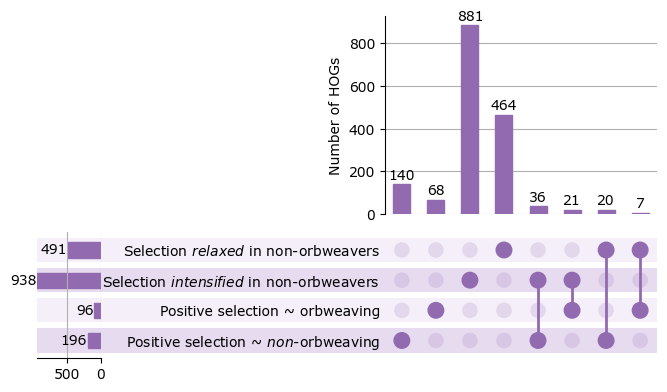

In [43]:
%autoreload 2
upset = up.UpSet(
    upset_data, show_counts=True, sort_categories_by=None, facecolor='#926AB0'
 )

# Only style categories that exist in the data
for cat, bar_color, shade_color in [
    ('Selection $\it{relaxed}$ in non-orbweavers', '#926AB0', '#F5EFF9'),
    ('Selection $\it{intensified}$ in non-orbweavers', '#926AB0', '#E7DBF0'),
    ('Positive selection ~ orbweaving', '#926AB0', '#F5EFF9'),
    ('Positive selection ~ $\it{non}$-orbweaving', '#926AB0', '#E7DBF0'),
]:
    if cat in hyphy_upset_dict:
        upset.style_categories(cat, bar_facecolor=bar_color, shading_facecolor=shade_color)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.show()
# plt.savefig(str(figures + '/figure_2/hyphy_upset.png'), dpi=300, transparent=False, bbox_inches='tight')

## UpSet plot of Hyphy results + silk genes/spidroins

In [44]:
upset_dict_with_silk = hyphy_upset_dict.copy()
upset_dict_with_silk['Silk gland-associated genes'] = hits_lists['silk_genes']
upset_dict_with_silk['Spidroins'] = hits_lists['spidroins']

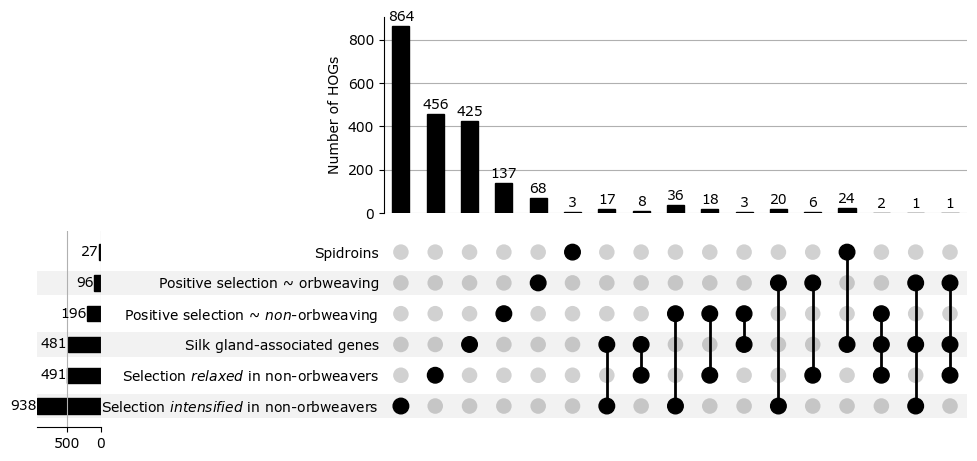

In [45]:
upset_data_with_silk = up.from_contents(upset_dict_with_silk)

upset = up.UpSet(
    upset_data_with_silk, show_counts=True,
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'

# Odds ratio test upset

In [46]:
upset_dict_with_ort = {}

upset_dict_with_ort["Gene count ~ non-orb-weaving"] = hits_lists['phyloglm_bg']
upset_dict_with_ort["Gene count ~ orb-weaving"] = hits_lists['phyloglm_fg']
upset_dict_with_ort['Duplication more likely in non-\norb-weavers'] = hits_lists['duplication_more_likely_nonorb']
upset_dict_with_ort['Duplication more likely in orb-weavers'] = hits_lists['duplication_more_likely_orb']
upset_dict_with_ort['Loss more likely in non-orb-weavers'] = hits_lists['loss_more_likely_nonorb']
upset_dict_with_ort['Loss more likely in orb-weavers'] = hits_lists['loss_more_likely_orb']

Text(0.5, 1.0, 'Odds ratio test')

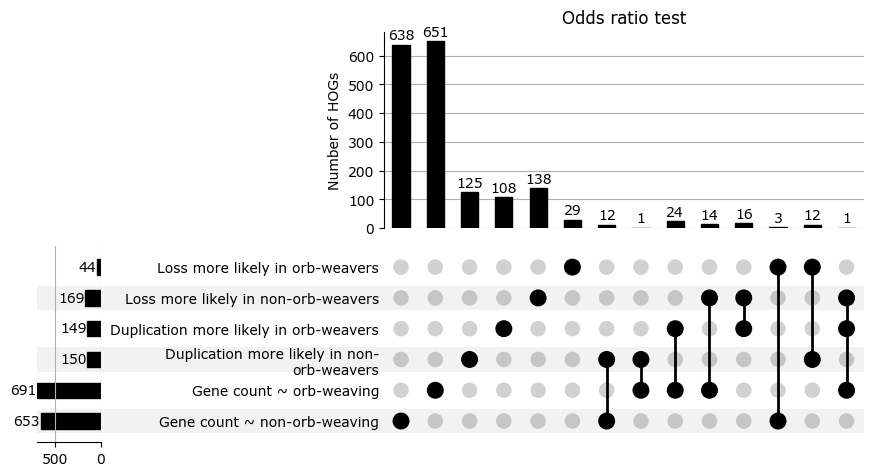

In [47]:
upset_data_with_ort = up.from_contents(upset_dict_with_ort)

upset = up.UpSet(
    upset_data_with_ort, show_counts=True, sort_categories_by=None
)

upset.plot()
plt.ylabel('Number of HOGs')
plt.rcParams['font.family'] = 'Verdana'
plt.title('Odds ratio test')
# 
# plt.savefig(str(figures + '/figure_5/ort_upset.png'), dpi=300, transparent=False, bbox_inches='tight')

## Odds ratio test upset with silk genes/spidroins

In [48]:
upset_dict_with_silk_ort = upset_dict_with_ort.copy()
upset_dict_with_silk_ort['Silk gland-associated genes'] = hits_lists['silk_genes']
upset_dict_with_silk_ort['Spidroins'] = hits_lists['spidroins']


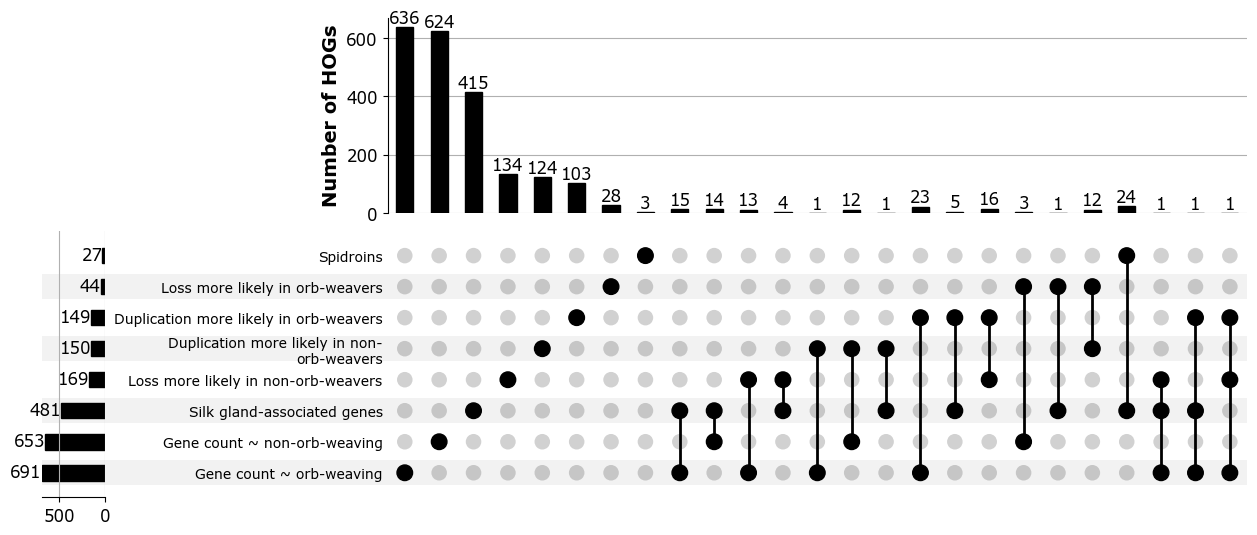

In [49]:
upset_data_with_silk_ort = up.from_contents(upset_dict_with_silk_ort)

upset = up.UpSet(
    upset_data_with_silk_ort, show_counts=False,
)

upset.plot()
plt.ylabel('Number of HOGs', fontsize=14, fontweight='bold')
plt.rcParams['font.family'] = 'Verdana'
plt.tick_params(axis='y', labelsize=12)

for ax in plt.gcf().axes:
    for bar in ax.containers:
        ax.bar_label(bar, fontsize=12)  # Bar numerical labels top
    if hasattr(ax, 'get_xticklabels'):
        plt.setp(ax.get_xticklabels(), fontsize=12) # Bar numerical labels bottom

# plt.savefig(str(figures + '/figure_5/ort_silk_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')


In [50]:
upset_dict_massive = upset_dict_with_ort | upset_dict_with_silk
# upset_dict_massive_50 = dict(reversed(list(upset_dict_massive_50.items())))
upset_dict_massive['Silk gland-associated genes'] = hits_lists['silk_genes']

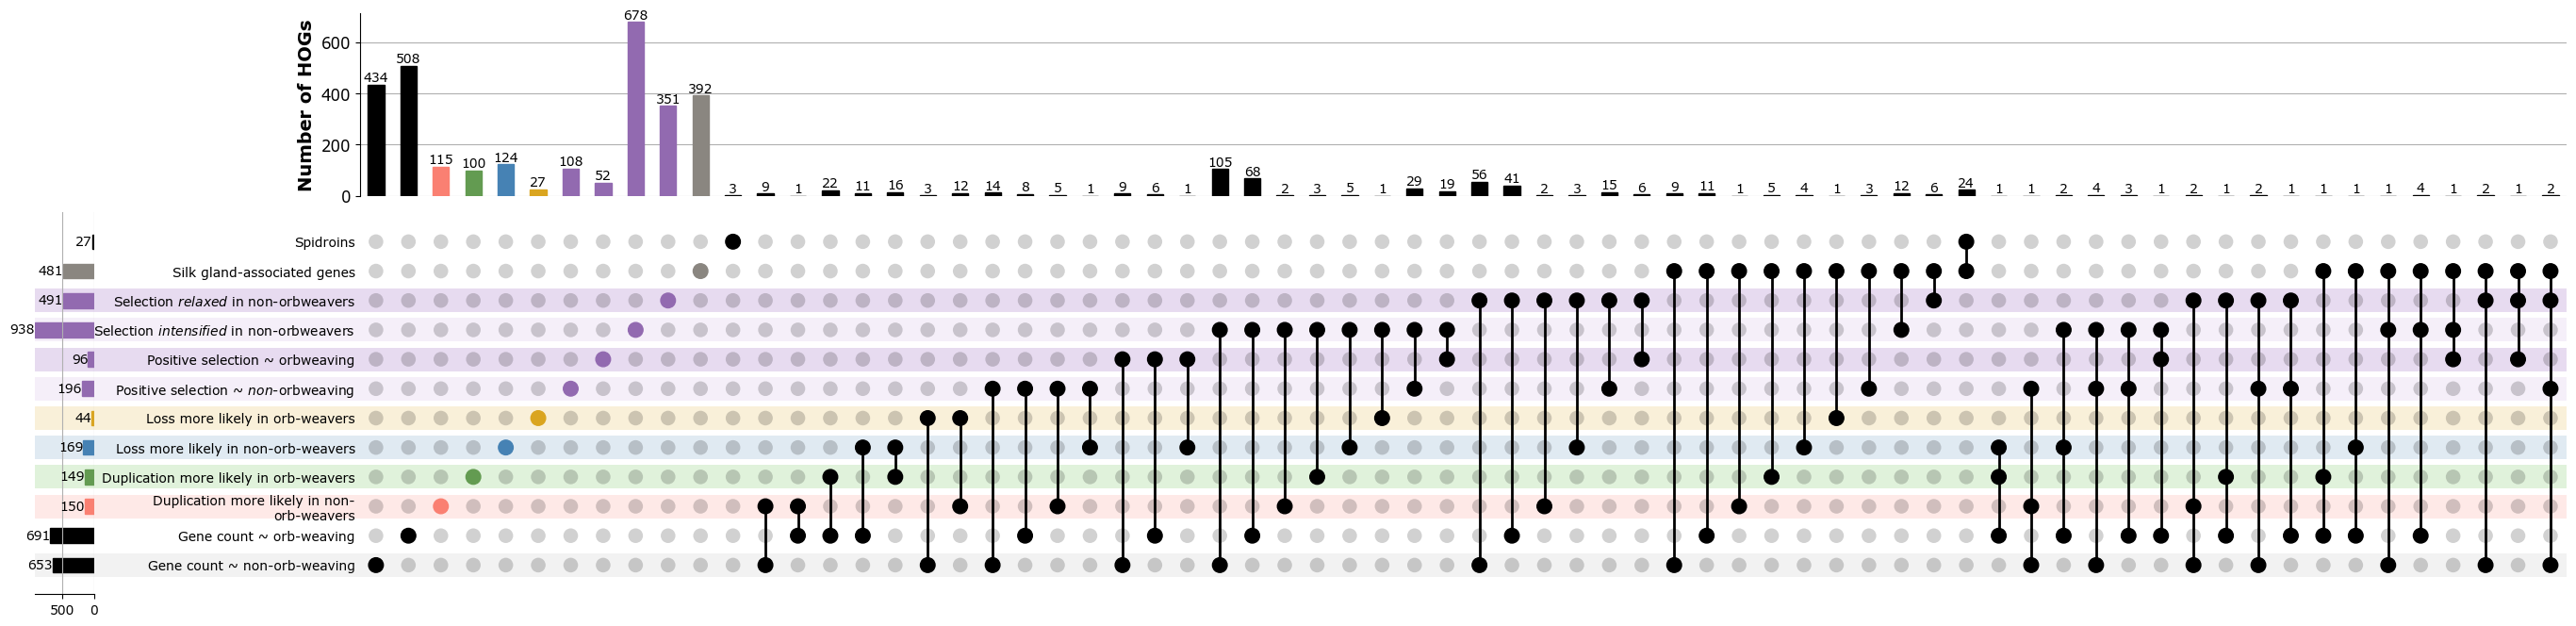

In [51]:
upset_data_massive = up.from_contents(upset_dict_massive)

upset = up.UpSet(
    upset_data_massive,
    sort_categories_by=None
)

upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#926AB0', shading_facecolor="#E7DBF0")
upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#926AB0', shading_facecolor='#F5EFF9')
upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#926AB0', shading_facecolor="#E7DBF0")
upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#926AB0', shading_facecolor="#F5EFF9")
# upset.style_categories('Selection $\it{relaxed}$ in non-orbweavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
# upset.style_categories('Positive selection ~ orbweaving', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
# upset.style_categories('Positive selection ~ $\it{non}$-orbweaving', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
# upset.style_categories('Selection $\it{intensified}$ in non-orbweavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')

upset.style_subsets(present=['Selection $\it{relaxed}$ in non-orbweavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Selection $\it{relaxed}$ in non-orbweavers'}),
                    facecolor="#926AB0")
upset.style_subsets(present=['Positive selection ~ orbweaving'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Positive selection ~ orbweaving'}),
                    facecolor="#926AB0")
upset.style_subsets(present=['Selection $\it{intensified}$ in non-orbweavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Selection $\it{intensified}$ in non-orbweavers'}),
                    facecolor="#926AB0")
upset.style_subsets(present=['Positive selection ~ $\it{non}$-orbweaving'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Positive selection ~ $\it{non}$-orbweaving'}),
                    facecolor="#926AB0")

upset.style_categories('Duplication more likely in non-\norb-weavers', bar_facecolor='#FA8072', shading_facecolor='#FEE9E7')
upset.style_categories('Loss more likely in non-orb-weavers', bar_facecolor='#4682B4', shading_facecolor='#E0EAF2')
upset.style_categories('Loss more likely in orb-weavers', bar_facecolor='#DAA520', shading_facecolor='#F9F0D9')
upset.style_categories('Duplication more likely in orb-weavers', bar_facecolor='#639B51', shading_facecolor='#E0F2DB')
upset.style_categories('Silk gland-associated genes', bar_facecolor='#8a8680', shading_facecolor='#FFFFFF')
# upset.style_categories('Spidroins', bar_facecolor='#8a8680', shading_facecolor='#E8DCF0')


upset.style_subsets(present=['Duplication more likely in non-\norb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Duplication more likely in non-\norb-weavers'}),
                    facecolor='#FA8072')
upset.style_subsets(present=['Loss more likely in non-orb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Loss more likely in non-orb-weavers'}),
                    facecolor='#4682B4')
upset.style_subsets(present=['Duplication more likely in orb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Duplication more likely in orb-weavers'}),
                    facecolor='#639B51')
upset.style_subsets(present=['Loss more likely in orb-weavers'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Loss more likely in orb-weavers'}),
                    facecolor='#DAA520')
upset.style_subsets(present=['Silk gland-associated genes'], 
                    absent=list(set(upset_dict_massive.keys()) - {'Silk gland-associated genes'}),
                    facecolor='#8a8680')
# upset.style_subsets(present=['Spidroins'], 
#                     absent=list(set(upset_dict_massive.keys()) - {'Spidroins'}),
#                     facecolor='#8a8680')

upset.plot()
plt.ylabel('Number of HOGs', fontsize=14, fontweight='bold')
plt.rcParams['font.family'] = 'Verdana'
plt.tick_params(axis='y', labelsize=12)

for ax in plt.gcf().axes:
    for bar in ax.containers:
        ax.bar_label(bar, fontsize=10)  # Bar numerical labels top
    if hasattr(ax, 'get_xticklabels'):
        plt.setp(ax.get_xticklabels(), fontsize=10) # Bar numerical labels bottom
# plt.savefig(str(figures + '/figure_6/massive_upset_plot.png'), dpi=300, transparent=False, bbox_inches='tight')

In [23]:
upset_dict_massive.keys() - {'Duplication more likely in non-orb-weavers'}

{'Duplication more likely in non-\norb-weavers',
 'Duplication more likely in orb-weavers',
 'Gene count ~ non-orb-weaving',
 'Gene count ~ orb-weaving',
 'Loss more likely in non-orb-weavers',
 'Loss more likely in orb-weavers',
 'Positive selection ~ $\\it{non}$-orbweaving',
 'Positive selection ~ orbweaving',
 'Selection $\\it{intensified}$ in non-orbweavers',
 'Selection $\\it{relaxed}$ in non-orbweavers',
 'Silk gland-associated genes',
 'Spidroins'}

## Get lists of genes significant in multiple analyses

In [24]:
def get_intersections(upset_dict, exclude=True):

    import itertools

    # Get all set names
    set_names = list(upset_dict.keys())

    # Convert lists to sets for set operations
    sets = {k: set(v) for k, v in upset_dict.items()}

    intersections = []

    # For all intersections (size 2 and up)
    for r in range(1, len(set_names) + 1):
        for combo in itertools.combinations(set_names, r):
            # Intersection of the selected sets
            intersect = sets[combo[0]].copy()
            for name in combo[1:]:
                intersect &= sets[name]
            if exclude:
                # Exclude elements present in any other set not in the combo (UpSet logic)
                other_sets = set(set_names) - set(combo)
                for name in other_sets:
                    intersect -= sets[name]
            if intersect:
                intersections.append((combo, sorted(intersect)))

    # Sort by decreasing length of intersection
    intersections.sort(key=lambda x: len(x[1]), reverse=True)

    # Remove intersections where the combo contains only one set
    intersections = [item for item in intersections if len(item[0]) > 1]

    # intersections now contains tuples: (combo, [elements]), sorted by size
    intersections_df = pd.DataFrame([
        {"Sets": ", ".join(combo), "Num_HOGs": len(hogs), "HOGs": ", ".join(hogs)}
        for combo, hogs in intersections
    ])

    intersections_df['HOG'] = intersections_df['HOGs'].apply(lambda x: x.split(", ") if pd.notnull(x) else [])

    return intersections_df

In [25]:
intersections = get_intersections(hits_lists)

In [26]:
intersections_expanded = intersections.explode('HOG').set_index('HOG', drop=True)[['Sets']]
intersections_expanded

,Sets
HOG,
N5.HOG0009118,"intensified_in_nonorb, phyloglm_bg"
N5.HOG0015944,"intensified_in_nonorb, phyloglm_bg"
N5.HOG0021146,"intensified_in_nonorb, phyloglm_bg"
N5.HOG0034646,"intensified_in_nonorb, phyloglm_bg"
N5.HOG0035416,"intensified_in_nonorb, phyloglm_bg"
...,...
N5.HOG0064389,"silk_genes, intensified_in_nonorb, loss_more_l..."
N5.HOG0052156,"relaxed_in_nonorb, positive_sel_in_nonorb, phy..."
N5.HOG0041902,"relaxed_in_nonorb, duplication_more_likely_non..."


In [27]:
intersections_locs = convert_hogs_to_locs(intersections_expanded, f'{data}/N5.tsv', one_random_gene=True)

Processing HOGs:   0%|          | 0/462 [00:00<?, ?it/s]

In [28]:
intersections_list_fltrd = intersections_locs[['HOG', 'Sets', 'LOC', 'GO_terms', 'Description']].drop_duplicates().reset_index(drop=True)
intersections_list_fltrd.rename(columns={
    'LOC': 'U. diversus gene ID',
    "GO_terms": "U. diversus GO terms", 
    "Description": "U. diversus gene description"
    }, inplace=True)
intersections_list_fltrd

,HOG,Sets,U. diversus gene ID,U. diversus GO terms,U. diversus gene description
0,N5.HOG0009118,"intensified_in_nonorb, phyloglm_bg",129220293,GO:0000278 [Name: mitotic cell cycle]; GO:0005...,tubulin alpha-8 chain-like
1,N5.HOG0015944,"intensified_in_nonorb, phyloglm_bg",129229561,GO:0006486 [Name: protein glycosylation]; GO:0...,"alpha-(1,3)-fucosyltransferase C-like"
2,N5.HOG0021146,"intensified_in_nonorb, phyloglm_bg",129224097,GO:2000779 [Name: regulation of double-strand ...,E3 ubiquitin-protein ligase TRIP12-like
3,N5.HOG0034646,"intensified_in_nonorb, phyloglm_bg",129228644,GO:0051015 [Name: actin filament binding]; GO:...,coronin-1C-A-like
4,N5.HOG0035416,"intensified_in_nonorb, phyloglm_bg",129222825,GO:0000086 [Name: G2/M transition of mitotic c...,M-phase inducer phosphatase-like
...,...,...,...,...,...
457,N5.HOG0064389,"silk_genes, intensified_in_nonorb, loss_more_l...",129233173,GO:0008254 [Name: 3'-nucleotidase activity]; G...,inositol monophosphatase 3-like
458,N5.HOG0052156,"relaxed_in_nonorb, positive_sel_in_nonorb, phy...",129228216,GO:0003924 [Name: GTPase activity]; GO:0007264...,Cell division cycle 42
459,N5.HOG0041902,"relaxed_in_nonorb, duplication_more_likely_non...",129221955,GO:0006357 [Name: regulation of transcription ...,polycomb group RING finger protein 3-like
460,N5.HOG0066116,"intensified_in_nonorb, duplication_more_likely...",129222991,GO:0004757 [Name: sepiapterin reductase activi...,sepiapterin reductase-like


In [29]:
intersection_df = get_ptep_description(intersections_list_fltrd)

In [30]:
intersection_df.to_excel(os.path.join(repo_root, 'results/Supplementary_Table_8_Hits_intersections.xlsx'), index=False)